In [1]:
import numpy as np
import glob
import cv2
import re
from tqdm import tqdm
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import matplotlib
import os
#import h5py
import matplotlib.cm as cm

In [20]:
#Change directories 
exp_name = '20241108_1'
curr_dir='/home/sam/bucket/Ants/trials/' + exp_name + '/data/'
output_folder_path = '/home/sam/bucket/sam/ant_tracking/' + exp_name + '/'
hmats_dir = '/home/sam/bucket/sam/ant_tracking//bundle_adjustment_paras.mat'
output_file_name = exp_name + '_aruco_panorama_frame.pkl'
col_1, col_2 = 9,11

In [21]:

def get_Hmats(dir):

    #how to load up parameters of the mapping
    mat = scipy.io.loadmat(dir)  
    paras = np.squeeze(mat['paras'])
    
    im_n = 25# set this to the number of images or the appropriate value
    H_pair = [[np.eye(3) if i == j else None for j in range(im_n)] for i in range(im_n)]
    for ii in range(1, im_n):
        currParams = paras[(4*(ii-1)):(4*ii)]
    
        S = np.array([[currParams[0], currParams[1], currParams[2]],
                      [currParams[1], currParams[0], currParams[3]]])
        H_pair[0][ii] = np.vstack([S, [0, 0, 1]])
        H_pair[ii][0] = np.linalg.inv(H_pair[0][ii])
    
    for i in range(1, im_n-1):
        for j in range(i+1, im_n):
            H_pair[i][j] = np.dot(H_pair[0][j], H_pair[i][0])
            H_pair[j][i] = np.linalg.inv(H_pair[i][j])
    
    H_mats = H_pair[13]
    H_mats_flipped = np.flip(H_mats, axis=0)
    return H_mats_flipped
    
def map_points(points, H):
    
    homogeneous_points = np.hstack([points, np.ones((points.shape[0], 1))])
    transformed_points_homogeneous = homogeneous_points @ H.T  # Matrix multiplication
    transformed_points = transformed_points_homogeneous[:, :2] / transformed_points_homogeneous[:, [2]]

    return transformed_points

def map_points_inv(points, H):
    
    transformed_points = np.hstack([points, np.ones((points.shape[0], 1))])
    original_points_homogeneous = transformed_points @ np.linalg.inv(H).T  # Matrix multiplication
    original_points = original_points_homogeneous[:, :2] / original_points_homogeneous[:, [2]]

    return original_points

def convert_to_pickle(folder_path, pickle_name, df_to_convert): 
    #Create a new folder with the combined files in the desired directory 
    folder_name = folder_path.split('/')[-2]
    if not os.path.exists(folder_path):
        # If the folder does not exist, create it
        os.makedirs(folder_path)
        print(f"Folder '{folder_name}' created in '{folder_path}'.")
    else:
        print(f"Folder '{folder_name}' already exists in '{folder_path}'.")

    df_to_convert.to_pickle(folder_path +  pickle_name )
    
    return

def check_calibration(xy_array):
    fig, ax = plt.subplots()
    ax.invert_yaxis()
    cmap = plt.colormaps['viridis']
    custom_cmap = cm.get_cmap(cmap, 25)
    for curr_cam in range(0,25):
        curr_H=H_mats[curr_cam]
        color = custom_cmap(curr_cam / (25 - 1))
        mapped_points=map_points(xy_array,curr_H)
        plt.plot(mapped_points[0:10000,0],mapped_points[0:10000,1],color=color)  
        plt.text(mapped_points[-1,0],mapped_points[-1,1], str(curr_cam))


def combine_aruco(H_mats, curr_dir): 
    #Retrieve all npy files in the current_directory if they are not frame counts 
    npy_files=glob.glob(curr_dir + '*.npy')
    
   

    max_instance=0

    #Set colormaps
    custom_cmap = plt.colormaps['viridis']

    #Setting the first camera 
    curr_cam = 0 
    
    df_aruco = pd.DataFrame(columns=['Cam','Frame_number', 'ARUCO_number', 'X', 'Y'])
    total_df_aruco =  df_aruco 
    #For each camera, map the points to the panorama using Hmats and load the new coordinates in a new df
    for npy in npy_files:
        #Extract the array 
        print('Treating file: ', npy)
        filename = npy.split('/')
        filename = filename[-1].split('_')
        curr_cam = int(filename[2][-2:]) - 1  # Adjust camera index)

        #Load the tracks
        aruco_tracks = np.load(npy)

        #Convert aruco to dataframe 
        num_frames, num_arucos, num_positions = aruco_tracks.shape
        reshaped_array = aruco_tracks.reshape((num_arucos * num_frames, num_positions))
        
        # Create a DataFrame from the reshaped array
        df_aruco = pd.DataFrame(reshaped_array, columns=['X', 'Y'])
        
        # Add columns for frame number and ARUCO number
        df_aruco['Frame_number'] = np.repeat(np.arange(num_frames), num_arucos)
        df_aruco['ARUCO_number'] = np.tile(np.arange(num_arucos), num_frames)
        

        df_aruco['Cam'] = np.ones(num_frames*num_arucos)*curr_cam
        
        # Reorder the columns
        df_aruco = df_aruco[['Cam','Frame_number', 'ARUCO_number', 'X', 'Y']]

        #cleanout the points (0,0)
        
        # Find indices where X and Y are equal
        zero_indices = df_aruco[(df_aruco['X'] == 0) & (df_aruco['Y'] == 0)].index
        # Drop rows with these indices
        df_aruco.drop(zero_indices, inplace=True)
 

        #Get the homography matrix 
        curr_H=H_mats[curr_cam]
        #curr_cam  += 1
    
        xy_array = df_aruco[['X', 'Y']].to_numpy()
        mapped_points=map_points(xy_array,curr_H)
        df_aruco['X']=mapped_points[:,0]
        df_aruco['Y']=mapped_points[:,1]  
        total_df_aruco=pd.concat([total_df_aruco,df_aruco], ignore_index=True)
        #print(total_df_aruco)
    return total_df_aruco 


In [27]:
#Faster processing 
def combine_aruco(H_mats, curr_dir):
    # Retrieve all .npy files in the current directory if they are not frame counts
    npy_files = glob.glob(os.path.join(curr_dir, '*.npy'))
    npy_files = [file for file in npy_files if 'global' not in file]
    
    total_aruco_data = []  # Use a list to store DataFrames for concatenation later

    # Set colormaps (not used in the function but keeping for future extension)
    custom_cmap = plt.get_cmap('viridis')

    # For each camera, map the points to the panorama using H_mats and load new coordinates into a DataFrame
    for npy_file in npy_files:
        # Extract camera index from the filename
        print('Processing file:', npy_file)
        curr_cam = int(os.path.basename(npy_file).split('_')[2][-2:]) - 1  # Adjust camera index

        # Load the tracks
        aruco_tracks = np.load(npy_file)

        # Reshape array and create DataFrame
        num_frames, num_arucos, num_positions = aruco_tracks.shape
        reshaped_array = aruco_tracks.reshape((num_arucos * num_frames, num_positions))
        df_aruco = pd.DataFrame(reshaped_array, columns=['X', 'Y'])
        
        # Add frame number, ARUCO number, and camera columns directly
        df_aruco['Frame_number'] = np.repeat(np.arange(num_frames), num_arucos)
        df_aruco['ARUCO_number'] = np.tile(np.arange(num_arucos), num_frames)
        df_aruco['Cam'] = curr_cam

        # Filter out rows where both X and Y are zero
        df_aruco = df_aruco[(df_aruco['X'] != 0) | (df_aruco['Y'] != 0)]

        # Map points using homography matrix
        curr_H = H_mats[curr_cam]
        xy_array = df_aruco[['X', 'Y']].to_numpy()
        mapped_points = map_points(xy_array, curr_H)
        
        # Update DataFrame with mapped points
        df_aruco[['X', 'Y']] = mapped_points

        # Append to the list for final concatenation
        total_aruco_data.append(df_aruco)

    # Concatenate all DataFrames at once
    total_df_aruco = pd.concat(total_aruco_data, ignore_index=True)
    
    return total_df_aruco


In [28]:
H_mats=get_Hmats(hmats_dir)

/tmp/ipykernel_10981/3797540669.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_cmap = cm.get_cmap(cmap, 25)


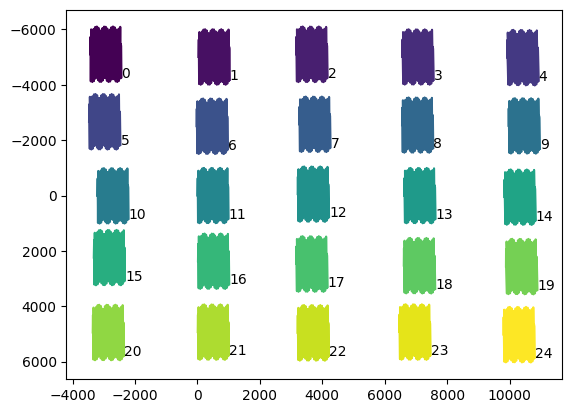

In [24]:
#Check the order of cameras 
x = np.linspace(0,1000,100)
y = 1000*np.sin(x)
xy_array = np.array([x.T, y.T])

#check_calibration(np.array(aruco_tracks_combined[['X','Y']]))
check_calibration(xy_array.T)

In [29]:
aruco_tracks_combined = combine_aruco(H_mats, curr_dir)

Processing file: /home/sam/bucket/Ants/trials/20241108_1/data/cam8_2024-11-07-23-41-04_cam17_001.aviaruco_tracks_.npy
Processing file: /home/sam/bucket/Ants/trials/20241108_1/data/cam1_2024-11-07-23-41-03_cam10_000.aviaruco_tracks_.npy
Processing file: /home/sam/bucket/Ants/trials/20241108_1/data/cam5_2024-11-07-23-40-20_cam23_004.aviaruco_tracks_.npy
Processing file: /home/sam/bucket/Ants/trials/20241108_1/data/cam0_2024-11-07-23-40-43_cam01_004.aviaruco_tracks_.npy
Processing file: /home/sam/bucket/Ants/trials/20241108_1/data/cam3_2024-11-07-23-40-20_cam21_000.aviaruco_tracks_.npy
Processing file: /home/sam/bucket/Ants/trials/20241108_1/data/cam4_2024-11-07-23-40-20_cam22_005.aviaruco_tracks_.npy
Processing file: /home/sam/bucket/Ants/trials/20241108_1/data/cam7_2024-11-07-23-41-03_cam16_002.aviaruco_tracks_.npy
Processing file: /home/sam/bucket/Ants/trials/20241108_1/data/cam3_2024-11-07-23-41-04_cam12_000.aviaruco_tracks_.npy
Processing file: /home/sam/bucket/Ants/trials/20241108_1

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots()
ax.invert_yaxis()
# Remove x-axis tick labels
#plt.gca().set_xticks([])
#plt.gca().set_yticks([])
plt.plot(aruco_tracks_combined['X'], aruco_tracks_combined['Y'], "o", markersize = 1)
plt.axis('off')
plt.show()

In [20]:
#Add a column with colony name
aruco_tracks_combined['Colony_name'] = aruco_tracks_combined['X'].apply(lambda x: col_1 if x < 2000 else col_2)


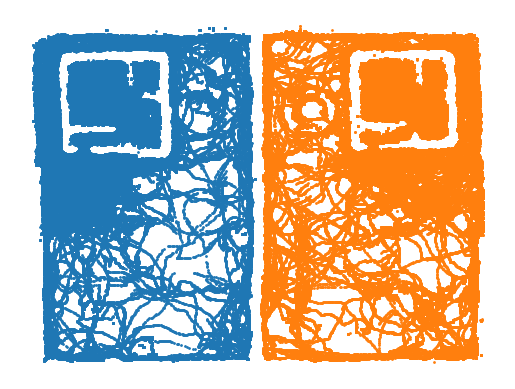

In [21]:
#Plot the tracks to verify the split 
colony_1 = aruco_tracks_combined[aruco_tracks_combined['Colony_name'] == col_1]
colony_2 = aruco_tracks_combined[aruco_tracks_combined['Colony_name'] == col_2]

fig, ax = plt.subplots()
ax.invert_yaxis()
# Remove x-axis tick labels
#plt.gca().set_xticks([])
#plt.gca().set_yticks([])
plt.plot(colony_1['X'], colony_1['Y'], "o", markersize = 1)
plt.plot(colony_2['X'], colony_2['Y'], "o", markersize = 1)
plt.axis('off')
plt.show()

In [22]:
convert_to_pickle(output_folder_path, output_file_name,aruco_tracks_combined)

Folder '20241110_1' already exists in '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/20241110_1/'.
